In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

**Dataset**


In [ ]:
(dataset_train, dataset_test), dataset_info = tfds.load(
    'cats_vs_dogs',
    split=['train[:80%]', 'train[80%:]'],
    as_supervised=True,
    with_info=True
)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cats_vs_dogs/incomplete.M4YME8_4.0.1/cats_vs_dogs-train.tfrecord*...:   0%…

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.


In [ ]:
IMG_SIZE = 128
BATCH_SIZE = 32

**Preprocessing**

In [ ]:
def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = image / 255.0
    return image, label

# Apply preprocessing
train_data = dataset_train.map(preprocess)
test_data = dataset_test.map(preprocess)

# Shuffle, Batch and Prefetch
train_data = train_data.shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_data = test_data.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


**Model**

In [ ]:
model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=10
)

Epoch 1/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 41s 57ms/step - accuracy: 0.6270 - loss: 0.6305 - val_accuracy: 0.7633 - val_loss: 0.4993
Epoch 2/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 30s 48ms/step - accuracy: 0.7625 - loss: 0.4979 - val_accuracy: 0.7700 - val_loss: 0.4931
Epoch 3/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 28s 47ms/step - accuracy: 0.8025 - loss: 0.4271 - val_accuracy: 0.8061 - val_loss: 0.4273
Epoch 4/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 29s 49ms/step - accuracy: 0.8363 - loss: 0.3713 - val_accuracy: 0.8293 - val_loss: 0.3842
Epoch 5/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 29s 48ms/step - accuracy: 0.8660 - loss: 0.3120 - val_accuracy: 0.8454 - val_loss: 0.3568
Epoch 6/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 29s 46ms/step - accuracy: 0.8900 - loss: 0.2604 - val_accuracy: 0.8405 - val_loss: 0.4059
Epoch 7/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 28s 46ms/step - accuracy: 0.9145 - loss: 0.2096 - val_accuracy: 0.8493 - val_loss: 0.4265
Epoch 8/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 28s 46ms/step - accuracy: 0.9311 - loss: 0.1693 - 

In [ ]:
loss, accuracy = model.evaluate(test_data)

print("\nTest Accuracy:", accuracy * 100, "%")

146/146 ━━━━━━━━━━━━━━━━━━━━ 7s 48ms/step - accuracy: 0.8469 - loss: 0.5526

Test Accuracy: 84.69475507736206 %


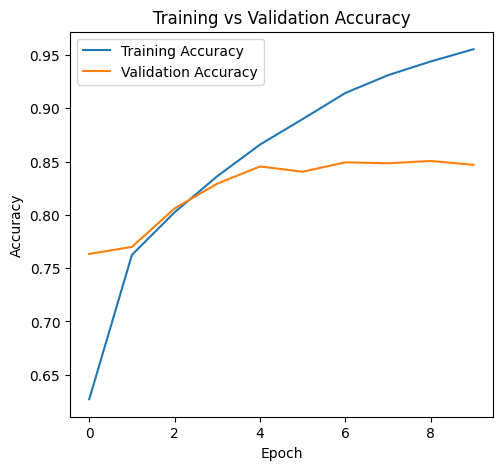

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

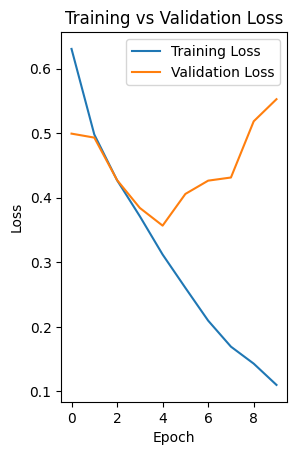

In [ ]:
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

**Prediction**

In [ ]:
img_path = '/dog1.jpg'
img = tf.keras.preprocessing.image.load_img(
    img_path,
    target_size=(IMG_SIZE, IMG_SIZE)
)

img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

print("\nPrediction Value:", prediction[0][0])

if prediction[0][0] > 0.5:
    print("The image is a DOG")
else:
    print("The image is a CAT")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step

Prediction Value: 0.99815375
The image is a DOG
